# 02. Robustness Check

---
### Executive Summary

이 프로젝트는 Kaggle의 **Home Credit Default Risk** 데이터셋을 활용해 진행했습니다. 해당 데이터셋은 실제 대출 기관(Home Credit)이 신용 이력이 부족한 고객(unbanked/underserved population)을 대상으로 한 신용평가 문제를 다루고 있어, 대출 상환 예측이라는 실무적 과제를 경험하기에 적합하다고 판단했습니다.

앞선 Feature Optimization 단계에서 발견한 특정 외부 신용 지표(EXT_SOURCE 계열)에 모델이 과도하게 의존하는 현상의 위험성을 검증하기 위해 진행했습니다.

현재 학습된 모델은 상위 10개 피처가 전체 모델 예측 성능의 약 **31%**를 차지하고 있었으며, 특히 EXT_SOURCE_MEAN을 비롯한 외부 신용평가 지표들이 최상위에 집중되어 있었습니다. 이는 unbanked/underserved 고객을 예측할 때 외부 데이터가 강력한 신호로 작용한다는 점에서는 긍정적이었으나, 동시에 **핵심 피처 의존도**에 대한 의문으로 이어졌습니다.

이를 확인하기 위해 다음 두 가지 Robustness 실험을 설계하고 수행했습니다:

1. **Feature Stress Test**  
   핵심 피처 상위 1~3위가 사라졌을 때의 모델 예측 성능을 확인하는 것으로, 나머지 약 480개 피처가 그 역할을 얼마나 잘 대체하는지 확인하는 실험입니다.

2. **집단 지표의 외부 신용 정보 대체 가능성 분석**  
   외부 평가 데이터의 대안으로 1등 솔루션에서 사용된 KNN 기반 피처(`neighbors_target_mean`)를 기존 핵심 피처의 대체제로서의 성능을 분석하는 실험입니다. 

이 과정을 통해 모델 성능을 세부적으로 분석하면서 **모델의 통계적 성능이 반드시 비즈니스 이익으로 연결되지 않으며, 데이터 거버넌스의 중요성과 모델의 전략적 견고성 확보가 중요하다**는 것을 배울 수 있었습니다.

다음으로는 정보가 전혀 없는 상태에서 진입하는 고객군을 어떻게 정의하고 평가할 것인지에 대한 Cold start 리스크 관리 방안에 대해 고민해보려 합니다.

### 1. Context & Objective
모델이 특정 task를 수행할 때 모델의 성능과 더불어 유지 가능성을 고려하는 것은 중요합니다. 모델 성능(AUC 0.789696)이 높게 나온 사실은 긍정적이지만, 모델 성능의 주요 지표가 외부 기관의 평가(ext_source 계열)인 것은 실제 운영 측면에서 제한을 가져다 줄 것입니다. 그러므로, 이 프로젝트에서는 **특정 지표들이 모델 성능에서 갖는 영향력**을 분석했습니다.

이를 위해 Feature Importance에서 상위 1~3위 피처들을 제거 후 모델 성능 변화를 분석하고, 새로운 피처의 대체 가능성을 정량적으로 평가했습니다.

### 2. Methodology
- 모델: **LightGBM** (5-fold CV, early stopping)
- Baseline(reduced model) vs 상위 피처 제거된 모델 vs 새로운 피처가 추가된 모델 성능 비교
- Noise Stress Test

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import seaborn as sns
import sklearn
import pickle 
import os

DATA_PATH = "data"

train = pd.read_csv(os.path.join(DATA_PATH, "train_full_cor.csv"))
test = pd.read_csv(os.path.join(DATA_PATH, "test_full_cor.csv"))
y = pd.read_csv(os.path.join(DATA_PATH, "y_full_cor.csv"))

In [4]:
y_target = y["TARGET"] if "TARGET" in y.columns else y.iloc[:, 0]
y_target.head() 

0    1
1    0
2    0
3    0
4    0
Name: TARGET, dtype: int64

#### 피처 불러오기

In [ ]:
import joblib

MODEL_PATH = "model"

# feature loading
try:
    features = joblib.load(os.path.join(MODEL_PATH, 'models/selected_features_483.pkl'))
    print(f"성공: {len(features)}개의 피처 리스트를 불러왔습니다.")
except FileNotFoundError:
    print("에러: 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

# feature checking
print(f"상위 피처 예시: {features[:5]}")

성공: 482개의 피처 리스트를 불러왔습니다.
상위 피처 예시: ['app_EXT_SOURCE_MEAN', 'app_EXT_SOURCE_3', 'app_EXT_SOURCE_2', 'buro_AMT_SUM_DEBT_RATIO_1_max', 'app_DAYS_EMPLOYED']


In [6]:
print(f"데이터 로드 완료: Train {train.shape}, Labels {y_target.shape}")
print(f"분석 대상 피처 수: {len(features)}개")

데이터 로드 완료: Train (307511, 1389), Labels (307511,)
분석 대상 피처 수: 482개


#### Baseline modeling

Reduced Model (483개 피처) 5-Fold OOF 학습 시작...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.095005 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 107706
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 482
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 300 rounds
[500]	training's auc: 0.830392	training's binary_logloss: 0.221156	valid_1's auc: 0.782511	valid_1's binary_logloss: 0.238404
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

<Figure size 700x500 with 0 Axes>

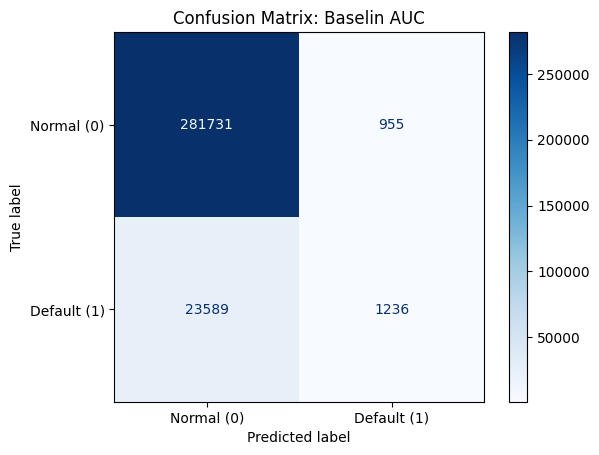

In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import gc
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# modeling setting
num_folds = 5
folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
oof_preds_reduced = np.zeros(train.shape[0]) 
valid_aucs_reduced = np.zeros(num_folds)

# modeling
gbm = lgb.LGBMClassifier(
    n_estimators=10000, 
    learning_rate=0.02,
    num_leaves=32,
    colsample_bytree=0.948,
    subsample=0.871,
    max_depth=8,
    reg_alpha=0.041,
    reg_lambda=0.073,
    min_split_gain=0.022,
    min_child_weight=39.32,
    random_state=42,
    n_jobs=-1
)

print(f"Reduced Model (483개 피처) 5-Fold OOF 학습 시작...")

# 5-Fold cross validation loop
for n_fold, (trn_idx, val_idx) in enumerate(folds.split(train, y_target)):
    
    # data split
    trn_x, trn_y = train[features].iloc[trn_idx], y_target.iloc[trn_idx]
    val_x, val_y = train[features].iloc[val_idx], y_target.iloc[val_idx]
    
    # model training
    gbm.fit(trn_x, trn_y, 
            eval_set = [(trn_x, trn_y), (val_x, val_y)], 
            eval_metric = "auc",
            callbacks = [
                lgb.early_stopping(stopping_rounds=300), 
                lgb.log_evaluation(period=500)
            ])
    
    # OOF prediction record (class 0, 1)
    best_iter = gbm.best_iteration_
    oof_preds_reduced[val_idx] = gbm.predict(val_x, num_iteration=best_iter)
    
    valid_preds_proba = gbm.predict_proba(val_x, num_iteration=best_iter)[:, 1]
    valid_aucs_reduced[n_fold] = roc_auc_score(val_y, valid_preds_proba)
    
    print(f"Fold {n_fold + 1} AUC: {valid_aucs_reduced[n_fold]:.6f}")
    
    del trn_x, trn_y, val_x, val_y
    gc.collect()

# final result output
print("\n" + "="*50)
print(f"Baseline AUC (483개): {np.mean(valid_aucs_reduced):.6f}")

# Confusion Matrix 
cm_reduced = confusion_matrix(y_target, oof_preds_reduced)

print("\n전체 데이터(OOF) Confusion Matrix 출력")
print("="*50)

# Visualization
plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_reduced, display_labels=['Normal (0)', 'Default (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix: Baselin AUC')
plt.show()


#### 3-1) 1위 피처 제거 후 모델 예측성능

[Stress Test] 'app_EXT_SOURCE_MEAN' 제거 후 재학습 시작...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 107451
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 481
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 300 rounds
[500]	training's auc: 0.810031	training's binary_logloss: 0.233647	valid_1's auc: 0.765302	valid_1's binary_logloss: 0.245666
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[1000]	training's auc: 0.841466	training's binary_logloss: 0.21944	valid_1's auc: 0.776598	valid_1's binary_logloss: 0.2407

<Figure size 700x500 with 0 Axes>

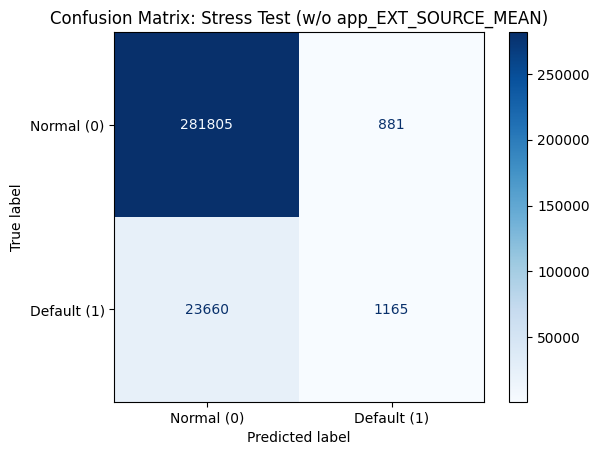

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import gc
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
seed = 42

# removing the top feature
target_feature = 'app_EXT_SOURCE_MEAN'
features_stress = [f for f in features if f != target_feature]

# modeling setting
num_folds = 5
folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)
valid_aucs_stress = np.zeros(num_folds)

# modeling
gbm = lgb.LGBMClassifier(n_estimators     = 10000,
                         learning_rate    = 0.005,
                         num_leaves       = 70,
                         colsample_bytree = 0.8,
                         subsample        = 0.9,
                         max_depth        = 7,
                         reg_alpha        = 0.1,
                         reg_lambda       = 0.1,
                         min_split_gain   = 0.01,
                         min_child_weight = 2,
                         random_state     = seed,
                         n_jobs           = 10)

oof_preds_class = np.zeros(train.shape[0])

print(f"[Stress Test] '{target_feature}' 제거 후 재학습 시작...")

for n_fold, (trn_idx, val_idx) in enumerate(folds.split(train, y_target)):
    
    # data split
    trn_x, trn_y = train[features_stress].iloc[trn_idx], y_target.iloc[trn_idx]
    val_x, val_y = train[features_stress].iloc[val_idx], y_target.iloc[val_idx]
    
    gbm.fit(trn_x, trn_y, 
            eval_set = [(trn_x, trn_y), (val_x, val_y)], 
            eval_metric = "auc",
            callbacks = [
                lgb.log_evaluation(period=500), 
                lgb.early_stopping(stopping_rounds=300)
            ])
    
    oof_preds_class[val_idx] = gbm.predict(val_x, num_iteration=gbm.best_iteration_)

    valid_preds = gbm.predict_proba(val_x, num_iteration=gbm.best_iteration_)[:, 1]
    valid_aucs_stress[n_fold] = roc_auc_score(val_y, valid_preds)
    
    print(f"Fold {n_fold + 1} Stress AUC: {valid_aucs_stress[n_fold]:.6f}")
    del trn_x, trn_y, val_x, val_y
    gc.collect()

# result comparison
baseline_auc = 0.789696 
stress_auc = np.mean(valid_aucs_stress)

print("\n" + "="*30)
print(f"Baseline AUC (483개): {baseline_auc:.6f}")
print(f"Stress Test AUC (482개): {stress_auc:.6f}")
print(f"성능 하락 폭 (Delta): {stress_auc - baseline_auc:.6f}")
print("="*30)
print("\n전체 데이터(OOF) Confusion Matrix 출력")

# confusion matrix
cm = confusion_matrix(y_target, oof_preds_class)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Default (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'Confusion Matrix: Stress Test (w/o {target_feature})')
plt.show()

In [9]:
from sklearn.metrics import classification_report

# 전체 데이터(OOF)에 대한 리포트 출력
print("📊 Classification Report (Stress Test)")
print(classification_report(y_target, oof_preds_class, target_names=['Normal', 'Default']))

📊 Classification Report (Stress Test)
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96    282686
     Default       0.57      0.05      0.09     24825

    accuracy                           0.92    307511
   macro avg       0.75      0.52      0.52    307511
weighted avg       0.89      0.92      0.89    307511



#### 3-2) 상위 피처 1, 2위가 사라졌을 때의 모델 예측성능

[Stress Test] '['app_EXT_SOURCE_MEAN', 'app_EXT_SOURCE_3']' 제거 후 재학습 시작...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 107196
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 480
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 300 rounds
[500]	training's auc: 0.807238	training's binary_logloss: 0.235813	valid_1's auc: 0.759382	valid_1's binary_logloss: 0.247901
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

<Figure size 700x500 with 0 Axes>

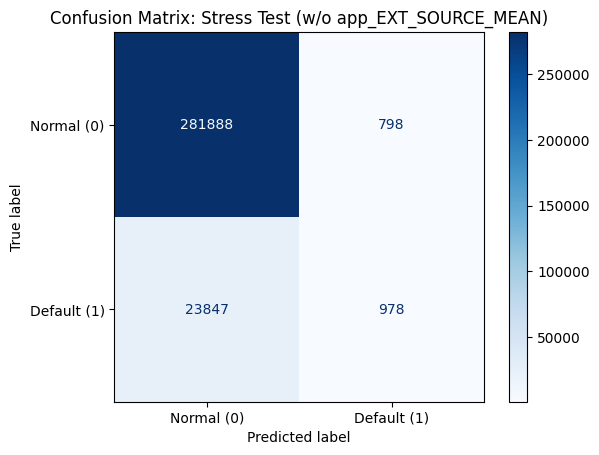

Classification Report (Stress Test)
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96    282686
     Default       0.55      0.04      0.07     24825

    accuracy                           0.92    307511
   macro avg       0.74      0.52      0.52    307511
weighted avg       0.89      0.92      0.89    307511



In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import gc
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
seed = 42

# removing the top 1, 2 features (1, 2위 피처 제외)
target_features = ['app_EXT_SOURCE_MEAN', 'app_EXT_SOURCE_3']
features_stress = [f for f in features if not f in target_features]

# model setting
num_folds = 5
folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)
valid_aucs_stress = np.zeros(num_folds)

# modeling
gbm = lgb.LGBMClassifier(n_estimators     = 10000,
                         learning_rate    = 0.005,
                         num_leaves       = 70,
                         colsample_bytree = 0.8,
                         subsample        = 0.9,
                         max_depth        = 7,
                         reg_alpha        = 0.1,
                         reg_lambda       = 0.1,
                         min_split_gain   = 0.01,
                         min_child_weight = 2,
                         random_state     = seed,
                         n_jobs           = 10)

oof_preds_class = np.zeros(train.shape[0])

print(f"[Stress Test] '{target_features}' 제거 후 재학습 시작...")

for n_fold, (trn_idx, val_idx) in enumerate(folds.split(train, y_target)):
    
    # data split
    trn_x, trn_y = train[features_stress].iloc[trn_idx], y_target.iloc[trn_idx]
    val_x, val_y = train[features_stress].iloc[val_idx], y_target.iloc[val_idx]
    
    gbm.fit(trn_x, trn_y, 
            eval_set = [(trn_x, trn_y), (val_x, val_y)], 
            eval_metric = "auc",
            callbacks = [
                lgb.log_evaluation(period=500), 
                lgb.early_stopping(stopping_rounds=300)
            ])
    
    oof_preds_class[val_idx] = gbm.predict(val_x, num_iteration=gbm.best_iteration_)

    valid_preds = gbm.predict_proba(val_x, num_iteration=gbm.best_iteration_)[:, 1]
    valid_aucs_stress[n_fold] = roc_auc_score(val_y, valid_preds)
    
    print(f"Fold {n_fold + 1} Stress AUC: {valid_aucs_stress[n_fold]:.6f}")
    del trn_x, trn_y, val_x, val_y
    gc.collect()

# result comparison
baseline_auc = 0.789696 
stress_auc = np.mean(valid_aucs_stress)

print("\n" + "="*30)
print(f"Baseline AUC (483개): {baseline_auc:.6f}")
print(f"Stress Test AUC (481개): {stress_auc:.6f}")
print(f"성능 하락 폭 (Delta): {stress_auc - baseline_auc:.6f}")
print("="*30)

# confusion matrix
cm = confusion_matrix(y_target, oof_preds_class)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Default (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'Confusion Matrix: Stress Test (w/o {target_feature})')
plt.show()

# classification report
print("Classification Report (Stress Test)")
print(classification_report(y_target, oof_preds_class, target_names=['Normal', 'Default']))

#### 3-3) 상위 피처 1, 2, 3위가 없어졌을 때 모델 예측성능

[Stress Test] '['app_EXT_SOURCE_MEAN', 'app_EXT_SOURCE_3', 'app_EXT_SOURCE_2']' 제거 후 재학습 시작...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 106941
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 479
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 300 rounds
[500]	training's auc: 0.800156	training's binary_logloss: 0.240199	valid_1's auc: 0.745846	valid_1's binary_logloss: 0.252582
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

<Figure size 700x500 with 0 Axes>

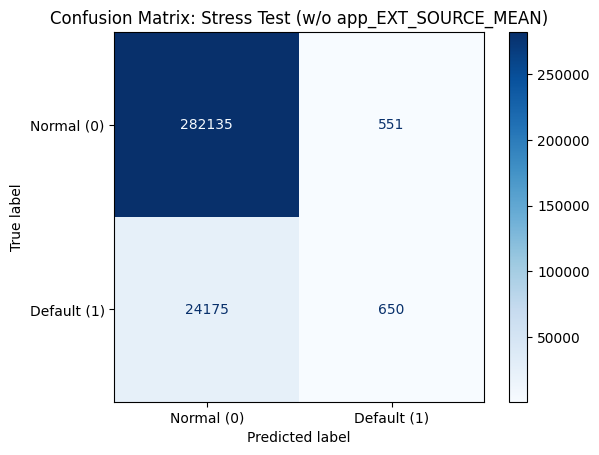

Classification Report (Stress Test)
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96    282686
     Default       0.54      0.03      0.05     24825

    accuracy                           0.92    307511
   macro avg       0.73      0.51      0.50    307511
weighted avg       0.89      0.92      0.88    307511



In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import gc
import warnings
warnings.filterwarnings("ignore")
seed = 42

# removing the top 1, 2, 3 features
target_features = ['app_EXT_SOURCE_MEAN', 'app_EXT_SOURCE_3', 'app_EXT_SOURCE_2']
features_stress = [f for f in features if not f in target_features]

# model setting
num_folds = 5
folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)
valid_aucs_stress = np.zeros(num_folds)

# modeling
gbm = lgb.LGBMClassifier(n_estimators     = 10000,
                         learning_rate    = 0.005,
                         num_leaves       = 70,
                         colsample_bytree = 0.8,
                         subsample        = 0.9,
                         max_depth        = 7,
                         reg_alpha        = 0.1,
                         reg_lambda       = 0.1,
                         min_split_gain   = 0.01,
                         min_child_weight = 2,
                         random_state     = seed,
                         n_jobs           = 10)

oof_preds_class = np.zeros(train.shape[0])

print(f"[Stress Test] '{target_features}' 제거 후 재학습 시작...")

for n_fold, (trn_idx, val_idx) in enumerate(folds.split(train, y_target)):
    
    # data split
    trn_x, trn_y = train[features_stress].iloc[trn_idx], y_target.iloc[trn_idx]
    val_x, val_y = train[features_stress].iloc[val_idx], y_target.iloc[val_idx]
    
    gbm.fit(trn_x, trn_y, 
            eval_set = [(trn_x, trn_y), (val_x, val_y)], 
            eval_metric = "auc",
            callbacks = [
                lgb.log_evaluation(period=500), 
                lgb.early_stopping(stopping_rounds=300)
            ])
    
    oof_preds_class[val_idx] = gbm.predict(val_x, num_iteration=gbm.best_iteration_)

    valid_preds = gbm.predict_proba(val_x, num_iteration=gbm.best_iteration_)[:, 1]
    valid_aucs_stress[n_fold] = roc_auc_score(val_y, valid_preds)
    
    print(f"Fold {n_fold + 1} Stress AUC: {valid_aucs_stress[n_fold]:.6f}")
    del trn_x, trn_y, val_x, val_y
    gc.collect()

# result comparison
baseline_auc = 0.789696 
stress_auc = np.mean(valid_aucs_stress)

print("\n" + "="*30)
print(f"Baseline AUC (483개): {baseline_auc:.6f}")
print(f"Stress Test AUC (481개): {stress_auc:.6f}")
print(f"성능 하락 폭 (Delta): {stress_auc - baseline_auc:.6f}")
print("="*30)

# confusion matrix
cm = confusion_matrix(y_target, oof_preds_class)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Default (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'Confusion Matrix: Stress Test (w/o {target_feature})')
plt.show()

# classification report
print("Classification Report (Stress Test)")
print(classification_report(y_target, oof_preds_class, target_names=['Normal', 'Default']))

In [13]:
prev = pd.read_csv("/Users/seunguk-lee/Desktop/my_project/HomeCreditDefault/venv_credit/data/previous_application.csv")

In [14]:
prev['AMT_APPLICATION'].mean()

np.float64(175233.86036042988)

### Feature Stress Test

상위 설명력 1~3위 피처(`EXT_SOURCE` 계열)는 전체 feature importance의 약 **22%**를 차지합니다. 이 핵심 피처들이 제거되었을 때 모델이 실제로 얼마나 영향을 받는지 confusion matrix를 통해 분석했습니다.

| 피처 제거 수준       | AUC      | AUC 변화량   | 전체 Default | False Negative (미탐지) | FN 증가량 | True Positive (탐지) | TP 감소량 |
|----------------------|----------|--------------|--------------|--------------------------|-----------|----------------------|-----------|
| Baseline (483개)    | 0.788979 | -            | 24,825      | 23,589                  | -         | 1,236               | -         |
| Top 1 제거          | 0.788733 | -0.000963    | 24,825      | 23,712                  | +52       | 1,113               | -52       |
| Top 1~2 제거        | 0.783119 | -0.006577    | 24,825      | 23,847                  | +187      | 978                 | -187      |
| Top 1~3 제거        | 0.771625 | -0.018071    | 24,825      | 24,175                  | +515      | 650                 | -515      |

분석 결과, 상위 3개 피처를 제거했을 때 AUC는 0.018 하락에 그쳤으나, **실제 부실 고객을 놓치는 수(False Negative)는 515건 증가**했습니다.

전체 신청자의 평균 대출 금액($175,233)과 LGD 60%를 적용해 보수적으로 추정했을 때, 이는 약 **$54.1M (약 750억 원)** 규모의 추가 잠재 손실 리스크로 이어질 수 있습니다.

즉, AUC라는 표면적 지표만으로는 성능 저하가 크지 않아 보이지만, 실제 대출 운영 환경에서는 **핵심 외부 피처 의존도로 인해 상당한 재무적 리스크가 발생할 수 있음**을 확인했습니다. 이는 외부 데이터에 대한 과도한 의존을 완화하고, 내부 데이터 기반의 대체 지표 개발이나 모델 안정성 강화가 필요하다는 점을 시사합니다.

#### 4) 집단 지표의 외부 신용 정보 대체 가능성 분석

1등 솔루션에서 높은 성능을 보였던 KNN 기반 피처(`neighbors_target_mean`)를 직접 구현하여 추가했습니다. 

이 피처는 해당 고객과 유사한 조건(예: 지역, 소득 수준, 신용 패턴 등)을 가진 주변 고객들의 평균 연체율을 계산하는 지표입니다. 외부 신용평가 기관(EXT_SOURCE)과는 다른 형태로, **비슷한 환경에 속한 집단의 통계**를 모델에 주입하는 방식입니다.

본 실험에서 다음 두 가지 질문에 대한 답을 찾고자 했습니다:
- 기존 상위 3개의 피처를 제거하고 새로운 피처를 추가했을 때 모델 성능이 어떻게 되는가?
- 새로운 피처로 학습시킨 모델은 개인 고객의 고유 특성과 집단 평균 중 어느 지표를 더 중요하게 반영하는가?

분석 결과는 SHAP을 활용하여 모델의 판단 근거를 시각화하여 '개인 지표'와 '집단 평균 특성' 반영 정도를 정량적으로 분석했습니다.

이를 통해 unbanked/underserved population을 대상으로 하는 신용평가 모델이라는 주제에서 **기존 방식과 대안의 성능을 종합적으로 고려** 했습니다. 

In [15]:
from sklearn.neighbors import NearestNeighbors
import gc

print("실험 2: 'neighbors_target_mean' 피처 생성 중...")

# Handling missing values 
knn_features = ['app_EXT_SOURCE_1', 'app_EXT_SOURCE_2', 'app_EXT_SOURCE_3']
knn_train = train[knn_features].fillna(train[knn_features].mean())

# training KNN model
knn = NearestNeighbors(n_neighbors=500, n_jobs=10)
knn.fit(knn_train)

# finding neigbors index
distances, indices = knn.kneighbors(knn_train)

# calaulting the average of neighbors 
train['neighbors_target_mean'] = np.array([y_target.iloc[idx].mean() for idx in indices])

print(f"피처 생성 완료. 새로운 피처 'neighbors_target_mean'이 추가되었습니다.")

# update the feature list
features_with_neighbor = features_stress + ['neighbors_target_mean']

실험 2: 'neighbors_target_mean' 피처 생성 중...
피처 생성 완료. 새로운 피처 'neighbors_target_mean'이 추가되었습니다.


Neighbor Model 분석 시작 (사용한 피처 수: 480개)
------------------------------------------------------------
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.107255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 107193
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 480
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 300 rounds
[500]	training's auc: 0.810319	training's binary_logloss: 0.232	valid_1's auc: 0.771317	valid_1's binary_logloss: 0.243454
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

<Figure size 800x600 with 0 Axes>

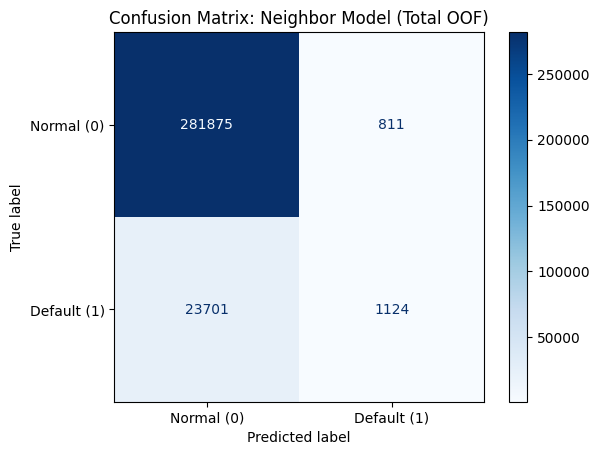


상세 분류 리포트 (Classification Report)
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96    282686
     Default       0.58      0.05      0.08     24825

    accuracy                           0.92    307511
   macro avg       0.75      0.52      0.52    307511
weighted avg       0.89      0.92      0.89    307511



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, roc_auc_score, classification_report, 
                             ConfusionMatrixDisplay, precision_score, recall_score)

warnings.filterwarnings("ignore")
seed = 42

# setting
oof_preds_proba = np.zeros(train.shape[0])
oof_preds_class = np.zeros(train.shape[0])
valid_aucs_neighbor = np.zeros(num_folds)

# data frame for feature importance
neighbor_importance_df = pd.DataFrame()

print(f"Neighbor Model 분석 시작 (사용한 피처 수: {len(features_with_neighbor)}개)")
print("-" * 60)

# CV loop
for n_fold, (trn_idx, val_idx) in enumerate(folds.split(train, y_target)):
    
    # data split
    trn_x, trn_y = train[features_with_neighbor].iloc[trn_idx], y_target.iloc[trn_idx]
    val_x, val_y = train[features_with_neighbor].iloc[val_idx], y_target.iloc[val_idx]
    
    # modeling
    gbm.fit(trn_x, trn_y, 
            eval_set=[(trn_x, trn_y), (val_x, val_y)], 
            eval_metric="auc",
            callbacks=[
                lgb.log_evaluation(period=500), 
                lgb.early_stopping(stopping_rounds=300)
            ])
    
    # implementing prediction
    best_iter = gbm.best_iteration_
    
    proba = gbm.predict_proba(val_x, num_iteration=best_iter)[:, 1]
    oof_preds_proba[val_idx] = proba
    
    preds = gbm.predict(val_x, num_iteration=best_iter)
    oof_preds_class[val_idx] = preds
    
    fold_auc = roc_auc_score(val_y, proba)
    valid_aucs_neighbor[n_fold] = fold_auc
    
    # recording feature importance
    fold_imp = pd.DataFrame({
        'Feature': features_with_neighbor,
        'Importance': gbm.feature_importances_,
        'Fold': n_fold + 1
    })
    neighbor_importance_df = pd.concat([neighbor_importance_df, fold_imp], axis=0)
    
    print(f"Fold {n_fold + 1:2d} | AUC: {fold_auc:.6f}")

    del trn_x, trn_y, val_x, val_y
    gc.collect()

# confusion matrix
total_auc = np.mean(valid_aucs_neighbor)
cm = confusion_matrix(y_target, oof_preds_class)
tn, fp, fn, tp = cm.ravel()

# visualization
print("\n" + "="*60)
print(f"[Neighbor Model 최종 결과 요약]")
print(f"Baseline AUC (483개) : {baseline_auc:.6f}")
print(f"Neighbor AUC (480개) : {total_auc:.6f}")
print(f"성능 향상 폭 (Delta)  : {total_auc - baseline_auc:.6f}")
print("="*60)

# Confusion Matrix 시각화
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Default (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'Confusion Matrix: Neighbor Model (Total OOF)')
plt.show()

# Classification Report 출력
print("\n상세 분류 리포트 (Classification Report)")
print(classification_report(y_target, oof_preds_class, target_names=['Normal', 'Default']))

In [19]:
# Feature importance ranking
top_imp_neighbor = neighbor_importance_df.groupby('Feature')['Importance'].mean().sort_values(ascending=False).reset_index()
print("\n새로운 Top 10 Features:")
print(top_imp_neighbor.head(10))


새로운 Top 10 Features:
                         Feature  Importance
0          neighbors_target_mean      4108.2
1               app_EXT_SOURCE_1      2987.0
2                 app_DAYS_BIRTH      2922.2
3                app_AMT_ANNUITY      2359.6
4                 app_AMT_CREDIT      2346.8
5  buro_AMT_SUM_DEBT_RATIO_1_max      2007.6
6            app_AMT_GOODS_PRICE      1893.8
7              app_DAYS_EMPLOYED      1820.4
8   buro_DAYS_CREDIT_ENDDATE_min      1802.0
9           buro_DAYS_CREDIT_min      1731.6


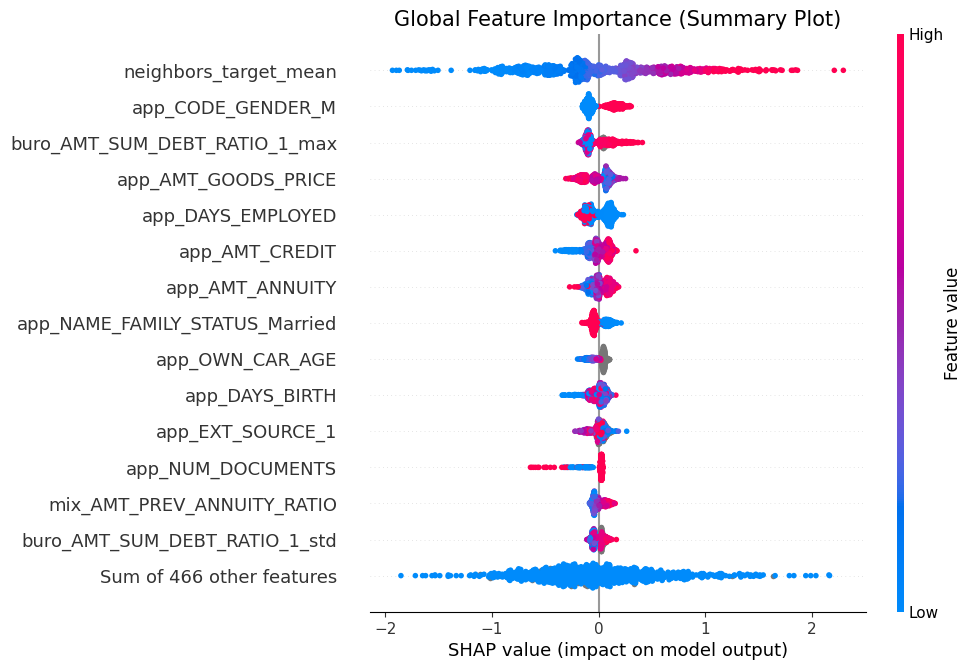

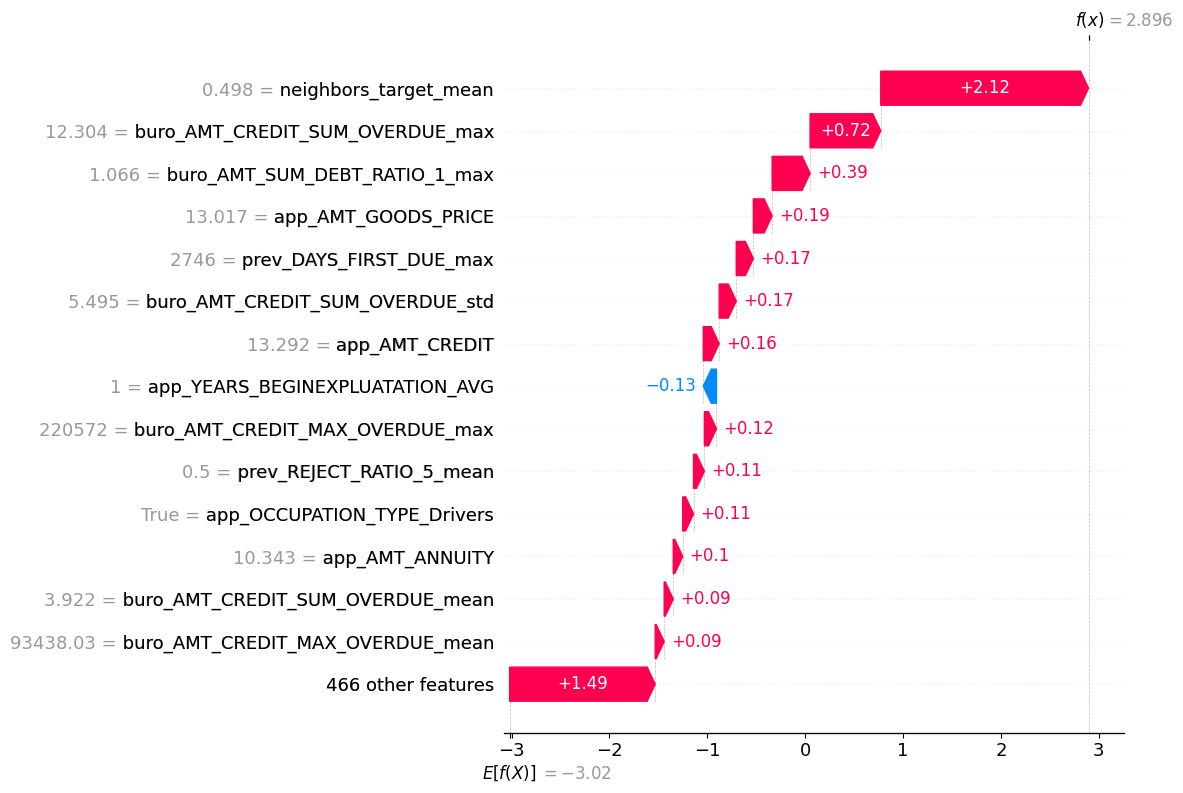

--- 분석 대상 고객 인덱스: 86307 ---
모델이 예측한 연체 확률: 0.9476


In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

all_preds = gbm.predict_proba(train[features_with_neighbor])[:, 1]
target_idx = np.argmax(all_preds) 

# SHAP explaination
explainer = shap.TreeExplainer(gbm)

# sampling with 1000 data
sample_data = train[features_with_neighbor].sample(n=min(1000, len(train)), random_state=42)
shap_values_all = explainer(sample_data)

target_instance = train[features_with_neighbor].iloc[target_idx : target_idx + 1]
sv_target = explainer(target_instance)


# SHAP plot
plt.figure(figsize=(10, 6))
plt.title(f"Global Feature Importance (Summary Plot)", fontsize=15)
shap.plots.beeswarm(shap_values_all, max_display=15) 

# Waterfall plot
plt.figure(figsize=(12, 8))
shap.plots.waterfall(sv_target[0], max_display=15)

print(f"--- 분석 대상 고객 인덱스: {target_idx} ---")
print(f"모델이 예측한 연체 확률: {all_preds[target_idx]:.4f}")

1등 솔루션에서 핵심 feature인 neighbors_target_mean 도입했을 때 모델의 성능을 confusion matrix를 통해 분석했습니다.

| 모델       | AUC      | AUC 변화량   | 전체 Default | False Negative (미탐지) | FN 증가량 | True Positive (탐지) | TP 감소량 |
|----------------------|----------|--------------|--------------|--------------------------|-----------|----------------------|-----------|
| Baseline (483개)    | 0.788979 | -            | 24,825      | 23,589                  | -         | 1,236               | -         |
| Neighbor Model  | 0.790604    | +0.000908      | 24,825              | 23,701       | +112      | 1,124         | -112        |

분석 결과, 핵심 피처(neighbors_target_mean)를 추가했을 때 모델 AUC는 0.000908 증가 하였으나, **실제 부실 고객을 놓치는 수(False Negative)는 112건이 증가** 하였습니다. 

위와 같은 조건으로 적용해본다면, 새로운 피처를 학습한 모델은 약 **$11.7M (약 174억)** 규모의 잠재 손실 리스크로 이어질 수 있습니다. 위 사례를 보면, 모델이 대출 상환 예측에 개인 지표들(CREDIT_SUM_OVERDUE_MAX, AMT_CREDIT 등 +0.72, +0.0.16)을 참고하지만 neighbors_target_mean(집단 평균) 피처는 가장 결정적인 요소(+ 2.12)로 작용되었습니다. 이는 새로 학습한 모델은 집단 평균을 더 중요하게 반영하는 것으로 나타났습니다. 

위 두 가지의 내용을 종합해 보자면, 기존 대출 상환 예측에서 중요하게 여겼던 피처들(EXT_SOURCE_*)은 외부 데이터라는 의존성 문제를 갖고 있었고 이를 대체하기 위해 사용된 집단 평균(neighbors_target_mean)은 모델의 AUC 성능 자체는 일부 향상 시켰지만 부실 고객을 놓치는 수가 증가하여 잠재적인 손실을 높이는 결과가 나왔습니다. 예측 과정에서 고객들의 개인 지표보단 소속된 집단 평균에 다소 집중된 양상을 보인만큼, 해당 피처의 대체 가능성은 부적절하다고 생각됩니다.
본 실험을 통해 통계적 지표 최적화(AUC 향상)가 비즈니스 이익으로 직결되지 않음을 발견했습니다.  

핵심 인사이트
1. Feature Stress Test
- 상위 1~3위 핵심 피처 제거 시, AUC는 **약 0.017** 하락 하였으나 **부실 미탐지는 515건 증가**
- 이는 **약 $90.2M**의 추가 손실을 발생할 수 있는 수치
- 단순 모델 성능 지표보다 비즈니스 목적에 맞게 설정하는 것이 중요 

2. 외부 신용 정보 대체 가능성 분석
- 1등 솔루션의 핵심 피처(neighbors_target_mean) 도입 결과 AUC는 **약 0.0009 개선**되었으나 **부실 미탐지는 112건 증가**
- 이는 손실 리스크를 **약 $11.7M**의 추가 손실을 발생할 수 있는 수치
- 신용 예측 과정에서 개인 지표보단 **집단 지표**에 집중됨
- 기존 피처 대비 높은 리스크 잠재성과 집단 지표 중심의 신용 예측으로 대체제로서 운용 메리트가 부적합. 이에 따라 새로운 내부적인 지표 개발이 필요로 함.

In [ ]:
import joblib
joblib.dump(gbm, os.path.join(MODEL_PATH, 'gbm_model_neighbor.pkl'))

['/Users/seunguk-lee/Desktop/my_project/HomeCreditDefault/venv_credit/models/gbm_model_neighbor.pkl']